# Quote-derived SSVI volatility surfaces

This notebook fits the restricted, statically arbitrage-free SSVI family to saved LSEG SPXW Close quotes and explicit same-date discount/forward inputs. It compares the fit with analytic Heston, inspects total variance and constraints, and separates strike holdout from maturity-interpolation tests.

All cells run offline. The selected fixture's actual date and hash are printed below. Model IV is not supplier IV; fit residuals are separate from implementation accuracy. Short/long maturity extrapolation is disabled. [SSVI specification](https://arxiv.org/abs/1204.0646).

In [1]:
from pathlib import Path
from time import perf_counter
import json
import sys
import math
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "tools").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from tools.market_validation import VolSurface, fit_ssvi
from tools.market_validation.snapshot import read_snapshot, dataset_hash, versions
from tools.market_validation.analytics import validate_snapshot
from tools.market_validation.calibration import calibrate, representatives

candidates = list((ROOT / "tests/fixtures/market").glob("lseg_spxw_*_surface.json"))
FIXTURE = max(candidates, key=lambda p: read_snapshot(p)["source"]["as_of"])
snapshot = read_snapshot(FIXTURE)
validated = validate_snapshot(snapshot)
SETTINGS = dict(starts=8, maxiter=2000, seed=42, diagnostics=True)
print("fixture:", FIXTURE.name)
print("provider/date:", snapshot["source"]["provider"], snapshot["source"]["as_of"])
print("dataset_sha256:", dataset_hash(snapshot))
print("accepted/rejected:", len(validated["accepted"]), len(validated["rejected"]))
print("settings:", SETTINGS)
print("versions:", versions())

fixture: lseg_spxw_20261008_surface.json
provider/date: LSEG 2026-10-08
dataset_sha256: 6a6a20fe0a700a3a560bf520e88f6bc84fbf186c6fd22bc7989f85307c68ba1f
accepted/rejected: 84 3
settings: {'starts': 8, 'maxiter': 2000, 'seed': 42, 'diagnostics': True}
versions: {'fuzzy-enigma': '0.1.0', 'lseg-data': '2.1.1', 'QuantLib': '1.40', 'scipy': '1.13.1', 'numpy': '1.26.4', 'pandas': '2.2.2', 'matplotlib': '3.9.0'}


In [2]:
started = perf_counter()
fit = fit_ssvi(validated, **SETTINGS)
ssvi_seconds = perf_counter() - started
assert fit["status"] == "converged", fit["status"]
surface = VolSurface.from_dict(fit["surface"])
started = perf_counter()
heston = calibrate(validated, starts=8, max_nfev=500, seed=42)
heston_seconds = perf_counter() - started
print("SSVI:", fit["status"], "elapsed_s:", round(ssvi_seconds, 3))
print("Heston:", heston["status"], "elapsed_s:", round(heston_seconds, 3))
for role in ("train", "holdout"):
    print(role, "SSVI:", fit[role], "Heston:", heston[role])
print("SSVI parameters:", fit["parameters"])
print("constraint diagnostics:", json.dumps(surface.diagnostics(), indent=2))

SSVI: converged elapsed_s: 1.469
Heston: converged elapsed_s: 6.921
train SSVI: {'count': 58, 'price_rmse': 2.69105357088799, 'weighted_rmse': 14.238460293281518, 'mean_abs_iv_error_bp': 181.67537925182245, 'iv_comparable_count': 58} Heston: {'count': 58, 'price_rmse': 4.237542473887956, 'weighted_rmse': 17.28392111136882, 'mean_abs_iv_error_bp': 135.8048953531996, 'iv_comparable_count': 58}
holdout SSVI: {'count': 12, 'price_rmse': 6.145308696110623, 'weighted_rmse': 20.921368533207545, 'mean_abs_iv_error_bp': 119.87027899586508, 'iv_comparable_count': 12} Heston: {'count': 12, 'price_rmse': 10.42920686388872, 'weighted_rmse': 33.78297830714737, 'mean_abs_iv_error_bp': 103.47815884224515, 'iv_comparable_count': 12}
SSVI parameters: {'rho': -0.4775335637729945, 'eta': 1.2608732544251202, 'theta_nodes': [{'expiry': '2026-10-15', 't': 0.019178082191780823, 'theta': 0.0001371577260822855}, {'expiry': '2026-10-22', 't': 0.038356164383561646, 'theta': 0.00037334439676874666}, {'expiry': '20

## Smiles and calibration residuals

Both fits use the same eligible OTM targets, fixed weights, and grouped strike holdout. Holdout observations do not initialize ATM nodes or select an optimizer start. A model can satisfy static no-arbitrage constraints while retaining residuals against conflicting Close observations.

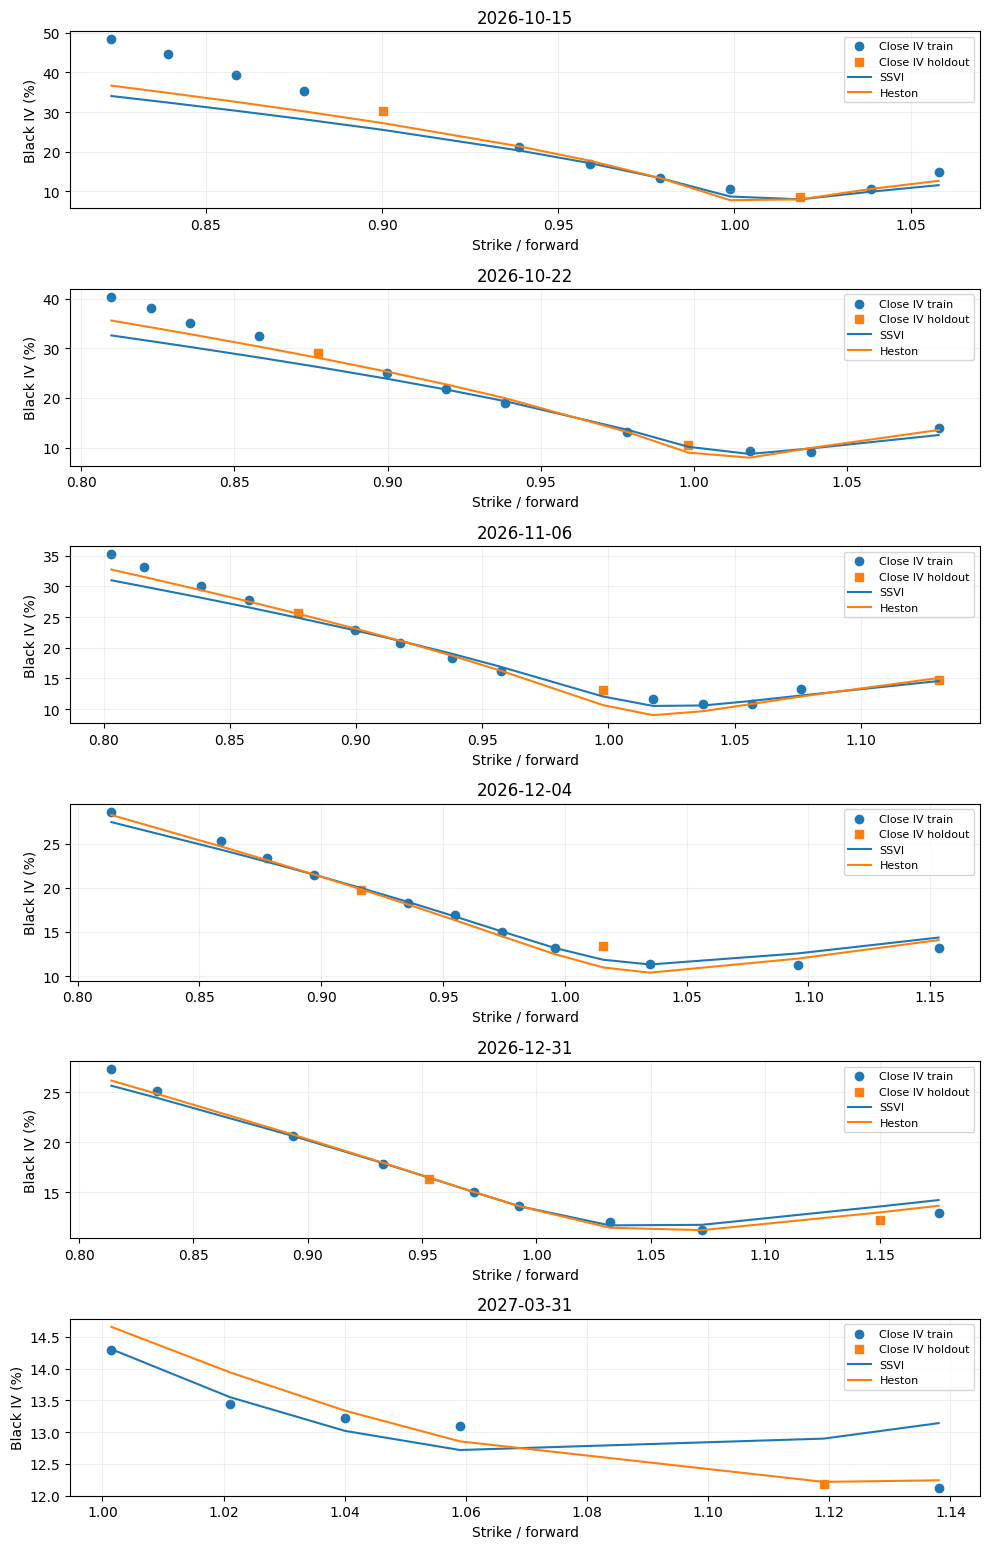

In [3]:
expiries = fit["qualifying_expiries"]
heston_by_group = {p["group"]: p for p in representatives(heston["predictions"])}
fig, axes = plt.subplots(len(expiries), 1, figsize=(10, 2.6 * len(expiries)), squeeze=False)
for ax, expiry in zip(axes[:, 0], expiries):
    rows = [p for p in fit["predictions"] if p["expiry"] == expiry and p["model_iv"] is not None]
    # Match the same OTM representatives used in both fits.
    rows = representatives(rows)
    rows.sort(key=lambda p: p["strike"])
    for role, marker in (("train", "o"), ("holdout", "s")):
        selected = [p for p in rows if p["split"] == role]
        ax.scatter([p["strike"] / p["forward"] for p in selected],
                   [100 * p["iv"] for p in selected], marker=marker, label="Close IV " + role)
    ax.plot([p["strike"] / p["forward"] for p in rows], [100 * p["model_iv"] for p in rows], label="SSVI")
    comparable = [heston_by_group[p["group"]] for p in rows
                  if heston_by_group.get(p["group"], {}).get("model_iv") is not None]
    ax.plot([p["strike"] / p["forward"] for p in comparable], [100 * p["model_iv"] for p in comparable], label="Heston")
    ax.set(title=expiry, xlabel="Strike / forward", ylabel="Black IV (%)")
    ax.grid(alpha=.2); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

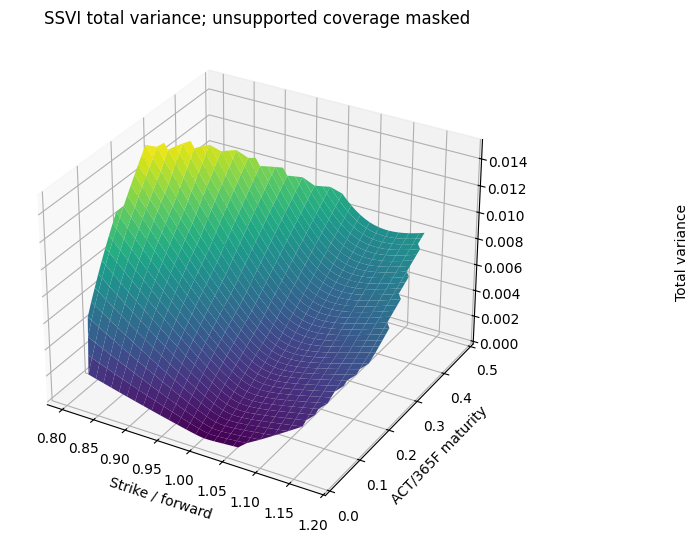

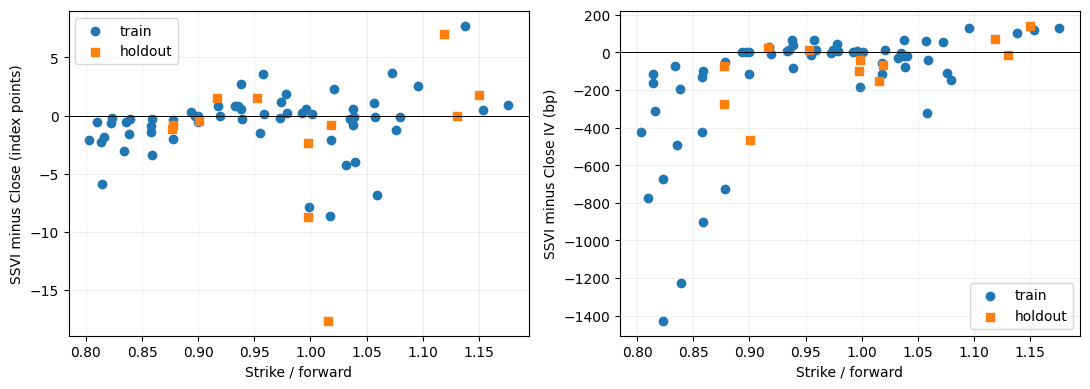

In [4]:
nodes = fit["surface"]["nodes"]
times = [node["t"] for node in nodes]
coords = [(math.log(p["strike"] / p["forward"]), p["t"]) for p in fit["predictions"]
          if p["expiry"] in expiries]
k_grid, t_grid = np.meshgrid(np.linspace(min(k for k, t in coords), max(k for k, t in coords), 55),
                            np.linspace(min(times), max(times), 40))
w_grid = np.full(k_grid.shape, np.nan)
for index in np.ndindex(k_grid.shape):
    try:
        w_grid[index] = surface.total_variance(float(k_grid[index]), float(t_grid[index]))
    except ValueError:
        pass  # Query policy masks unsupported observed coverage.
fig = plt.figure(figsize=(11, 5.5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(np.exp(k_grid), t_grid, w_grid, cmap="viridis", linewidth=0)
ax.set(xlabel="Strike / forward", ylabel="ACT/365F maturity", zlabel="",
       title="SSVI total variance; unsupported coverage masked")
# Leave room for the 3D z-axis label in saved notebook output.
ax.set_position([0.0, 0.05, 0.82, 0.90])
fig.text(0.79, 0.55, "Total variance", rotation=90, va="center")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for role, marker in (("train", "o"), ("holdout", "s")):
    rows = [p for p in representatives(fit["predictions"]) if p["split"] == role and p["model_price"] is not None]
    axes[0].scatter([p["strike"] / p["forward"] for p in rows], [p["price_error"] for p in rows], marker=marker, label=role)
    comparable = [p for p in rows if p.get("iv_error_bp") is not None]
    axes[1].scatter([p["strike"] / p["forward"] for p in comparable], [p["iv_error_bp"] for p in comparable], marker=marker, label=role)
for ax in axes:
    ax.axhline(0, color="black", lw=.7); ax.set_xlabel("Strike / forward"); ax.grid(alpha=.2); ax.legend()
axes[0].set_ylabel("SSVI minus Close (index points)")
axes[1].set_ylabel("SSVI minus Close IV (bp)")
fig.tight_layout(); plt.show()

## Constraint margins, maturity holdouts, and input sensitivities

The analytic parameter conditions certify the selected family; a dense numerical scan is supplementary. Total variance is non-decreasing at fixed forward moneyness, while annualised IV need not be monotone.

Each interior-expiry fold removes that expiry and its ATM node, rebuilds the training-only initializer, and tests interpolation. Carry scenarios shift risk-free or dividend yield by ±1 bp. Weight scenarios change the assumed Close IV uncertainty to 0.5%/2%, retaining measured historical spread weights. These are input diagnostics, not investment-return forecasts.

fit diagnostics: {
  "static_arbitrage": {
    "passed": true,
    "analytic_certificate": "restricted SSVI sufficient conditions, Gatheral-Jacquier Corollary4.1/Eq4.5",
    "min_density_g": 0.2501845666335506,
    "min_calendar_derivative": 0.008694559389544554,
    "max_wing_slope": 0.0919603393305852,
    "constraint_margins": {
      "eta_margin": 0.13701744692319862,
      "required_epsilon": 1e-06,
      "rho_margin": 0.5224664362270055,
      "minimum_theta": 0.0001371577260822855,
      "minimum_theta_increment": 0.00023618667068646117
    },
    "scan_grid": {
      "times": [
        0.019178082191780823,
        0.028767123287671233,
        0.038356164383561646,
        0.058904109589041104,
        0.07945205479452055,
        0.1178082191780822,
        0.15616438356164383,
        0.19315068493150683,
        0.23013698630136986,
        0.35342465753424657,
        0.4767123287671233
      ],
      "k_min": -10,
      "k_max": 10,
      "points_per_time": 405,
      "me

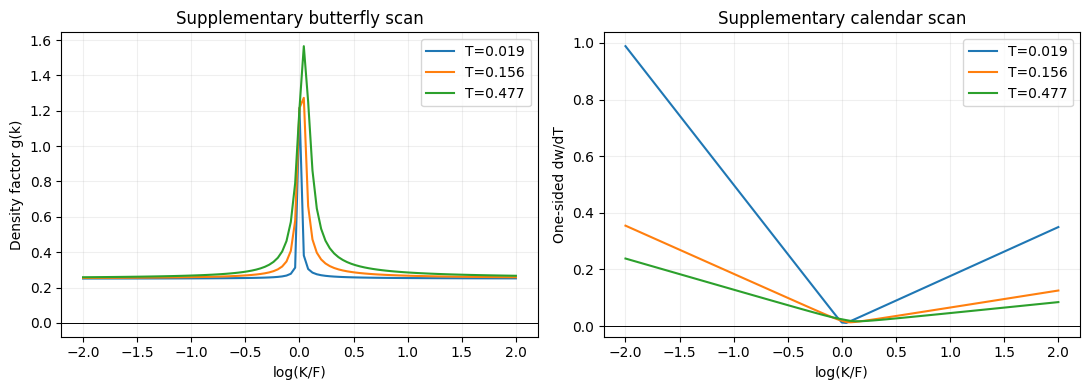

In [5]:
print("fit diagnostics:", json.dumps(fit["diagnostics"], indent=2))
print("interior-expiry holdouts:")
for fold in fit["expiry_holdouts"]:
    print({key: fold.get(key) for key in ("held_out_expiry", "status", "train", "holdout", "chosen_start")})
print("sensitivity summaries:")
for item in fit["sensitivities"]:
    print({key: item.get(key) for key in ("category", "name", "status", "train", "holdout", "comparison")})

# Every scan query is within the fitted maturity range; wing requests are explicit.
k_scan = np.linspace(-2, 2, 101)
t_scan = np.linspace(min(times), max(times), 35)
minimum_calendar = min(surface.derivatives(float(k), float(t), allow_wing=True)["w_t"]
                       for k in k_scan for t in t_scan)
print("minimum w_t on supplementary wing/time scan:", minimum_calendar)
assert minimum_calendar >= -1e-10

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for t in (times[0], times[len(times)//2], times[-1]):
    values = [surface.derivatives(float(k), t, allow_wing=True) for k in k_scan]
    density_g = [(1 - d["k"] * d["w_k"] / (2*d["w"]))**2
                 - d["w_k"]**2 / 4 * (1/d["w"] + .25) + d["w_kk"] / 2 for d in values]
    axes[0].plot(k_scan, density_g, label=f"T={t:.3f}")
    axes[1].plot(k_scan, [d["w_t"] for d in values], label=f"T={t:.3f}")
for ax in axes:
    ax.axhline(0, color="black", lw=.7); ax.set_xlabel("log(K/F)"); ax.grid(alpha=.2); ax.legend()
axes[0].set_ylabel("Density factor g(k)"); axes[0].set_title("Supplementary butterfly scan")
axes[1].set_ylabel("One-sided dw/dT"); axes[1].set_title("Supplementary calendar scan")
fig.tight_layout(); plt.show()
